---
title: "Stakeholder Thematic Analysis"
format:
  html:
    embed-resources: true
    theme: cosmo
execute:
  echo: false
---

In [47]:
#| output: false

import pandas as pd
import re


df_raw = pd.read_csv('Data_Figures_nancy.csv', header=None)

# Column names
cols = [
    'Term', 'Expert', 'LCM', 'Interviews', 'Workshops', 
    'LCM_Cat', 'Expert_Cat', 'Interviews_Cat', 'Workshops_Cat'
]
df_tidy = df_raw.iloc[2:].copy() # Skip the first two header rows
df_tidy.columns = cols

# Category
category_mask = df_raw.iloc[2:, 6].notna()
df_tidy['Category_Raw'] = None
df_tidy.loc[category_mask, 'Category_Raw'] = df_tidy.loc[category_mask, 'Term']
df_tidy['Category_Raw'] = df_tidy['Category_Raw'].ffill()


def clean_text(text):
    if pd.isna(text): return ""
    return re.sub(r'^[0-9.]+\s*', '', str(text)).strip()

df_tidy['Category'] = df_tidy['Category_Raw'].apply(clean_text)
df_tidy['SubCategory'] = df_tidy['Term'].apply(clean_text)


metrics = ['Expert', 'LCM', 'Interviews', 'Workshops']
for col in metrics:
    df_tidy[col] = pd.to_numeric(df_tidy[col], errors='coerce').fillna(0)

# Columns needed for Wrangle
df_final = df_tidy[['Category', 'SubCategory', 'Expert', 'LCM', 'Interviews', 'Workshops']]
df_final.to_csv('tidy_data.csv', index=False)

print("Tidy script complete. 'tidy_data.csv' is ready for wrangling.")

Tidy script complete. 'tidy_data.csv' is ready for wrangling.


In [48]:
#| output: false

df = pd.read_csv('tidy_data.csv')

# Pivot table with Categories as rows and Sub-categories as the "stacks" in our bar
pivot_df = df.pivot_table(
    index='Category', 
    columns='SubCategory', 
    values='Expert', 
    aggfunc='sum'
).fillna(0)

# Sorting

category_totals = pivot_df.sum(axis=1).sort_values(ascending=False)

pivot_df_sorted = pivot_df.loc[category_totals.index]

# Save wrangled data
pivot_df_sorted.to_csv('wrangled_data_for_plot.csv')
print("Wrangling complete: Data is sorted and pivoted.")

Wrangling complete: Data is sorted and pivoted.


In [49]:
#| output: false

df = pd.read_csv('Data_Figures_nancy.csv', skiprows=1)


cols = [
    'Terms', 
    'Sub_Expert', 'Sub_LCM', 'Sub_Interviews', 'Sub_Workshops',
    'Cat_LCM', 'Cat_Expert', 'Cat_Interviews', 'Cat_Workshops'
]
df.columns = cols


numeric_cols = cols[1:]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')


print(df.head())

category_totals = df[['Cat_LCM', 'Cat_Expert', 'Cat_Interviews', 'Cat_Workshops']].sum()
print("\nCategory Totals:")
print(category_totals)

            Terms  Sub_Expert  Sub_LCM  Sub_Interviews  Sub_Workshops  \
0   1.1 Interface          15       14               2             14   
1     1.2 Between           5        3               2              3   
2  1.3 Surrounded           0        6               1              5   
3   1.4 Proximity          13       36              14             26   
4   1.5. Part of            3       24              15             10   

   Cat_LCM  Cat_Expert  Cat_Interviews  Cat_Workshops  
0     86.0        40.0            38.0           60.0  
1      NaN         NaN             NaN            NaN  
2      NaN         NaN             NaN            NaN  
3      NaN         NaN             NaN            NaN  
4      NaN         NaN             NaN            NaN  

Category Totals:
Cat_LCM           374.0
Cat_Expert        186.0
Cat_Interviews    180.0
Cat_Workshops     263.0
dtype: float64


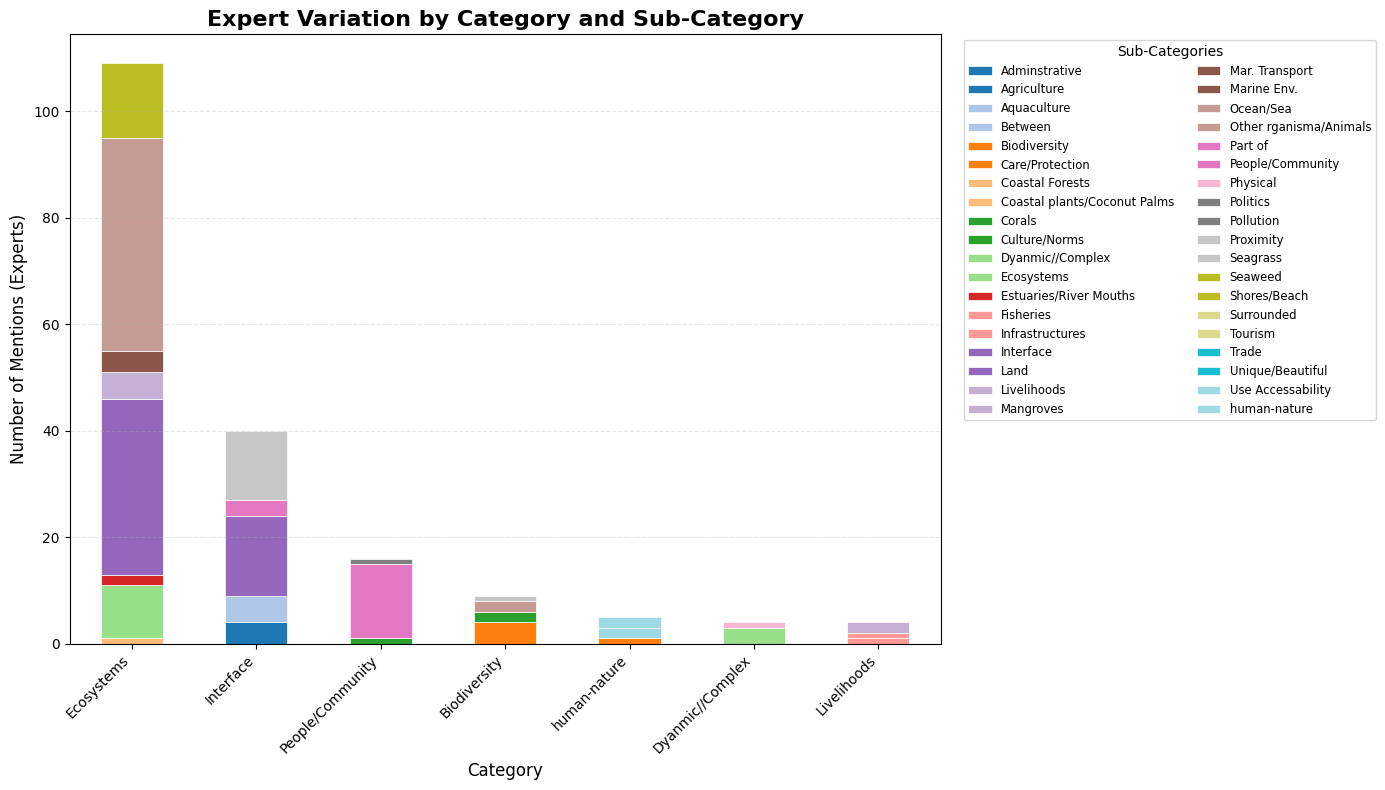

In [50]:
import matplotlib.pyplot as plt

ax = pivot_df_sorted.plot(
    kind='bar', 
    stacked=True, 
    figsize=(14, 8), 
    colormap='tab20',
    edgecolor='white',
    linewidth=0.5
)

# Labels and title
plt.title('Expert Variation by Category and Sub-Category', fontsize=16, fontweight='bold')
plt.ylabel('Number of Mentions (Experts)', fontsize=12)
plt.xlabel('Category', fontsize=12)


plt.xticks(rotation=45, ha='right')

# Legend optimization
plt.legend(
    title='Sub-Categories', 
    bbox_to_anchor=(1.02, 1), 
    loc='upper left', 
    fontsize='small', 
    ncol=2,                
    frameon=True  
)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()

plt.savefig('final_visualization_distinct.png', dpi=300)
plt.show()

# Thematic Consesus

Ecosystems: The anchor of the study, capturing over 50% of mentions across every group. There is a universal technical and practical agreement that Ocean and Land are the primary defining elements of the region.

Interface: It represents a shared understanding of the coastal zone as a space defined by proximity. It highlights that all stakeholders view the coast as a series of interconnected physical relationships.

Biodiversity & Dynamic/Complex: They serve as functional attributes. While Experts use them to define physical and biological structural complexity, they represent a smaller, more fragmented portion of the overall.

Livelihoods: Represents the greatest area of dispute. Local stakeholders (LCM) and Interviewees view the environment through the lens of survival and economy (Fisheries, Tourism).

People/Community: More prominent in Workshops and Interviews, showing that participatory methods are better at capturing the human and social dimensions of coastal management than purely technical expert assessments.

Human-Nature: Acts as a bridge, focusing on impacts and benefits. It is a minor but consistent theme, indicating an emerging recognition of the feedback loops between human activity and environmental health.

In [51]:
#| output: false

# Data with specific column names
headers = ['Terms', 'Sub_Expert', 'Sub_LCM', 'Sub_Interviews', 'Sub_Workshops', 'Cat_LCM', 'Cat_Expert', 'Cat_Interviews', 'Cat_Workshops']
df = pd.read_csv('Data_Figures_nancy.csv', skiprows=2, names=headers)

# Categories for each row
current_category = None
cleaned_data = []

for idx, row in df.iterrows():
    if pd.notnull(row['Cat_LCM']):
        current_category = row['Terms']
    
    if any(pd.notnull(row[['Sub_Expert', 'Sub_LCM', 'Sub_Interviews', 'Sub_Workshops']])):
        cleaned_data.append({
            'Category': current_category,
            'SubCategory': row['Terms'],
            'Expert': row['Sub_Expert'],
            'LCM': row['Sub_LCM'],
            'Interviews': row['Sub_Interviews'],
            'Workshops': row['Sub_Workshops']
        })

df_clean = pd.DataFrame(cleaned_data)
df_clean[['Expert', 'LCM', 'Interviews', 'Workshops']] = df_clean[['Expert', 'LCM', 'Interviews', 'Workshops']].fillna(0)

pivot_df = df_clean.pivot_table(
    index='Category', 
    columns='SubCategory', 
    values='Expert', 
    aggfunc='sum'
).fillna(0)

print(pivot_df)

SubCategory           1.1 Interface  1.2 Between  1.3 Surrounded  \
Category                                                           
1.1 Interface                  15.0          5.0             0.0   
2.1 Dyanmic//Complex            0.0          0.0             0.0   
2.2 Biodiversity                0.0          0.0             0.0   
2.3 Ecosystems                  0.0          0.0             0.0   
3.1 People/Community            0.0          0.0             0.0   
3.2 Livelihoods                 0.0          0.0             0.0   
3.3. human-nature               0.0          0.0             0.0   

SubCategory           1.4 Proximity  1.5. Part of   1.6 Adminstrative  \
Category                                                                
1.1 Interface                  13.0            3.0                4.0   
2.1 Dyanmic//Complex            0.0            0.0                0.0   
2.2 Biodiversity                0.0            0.0                0.0   
2.3 Ecosystems        

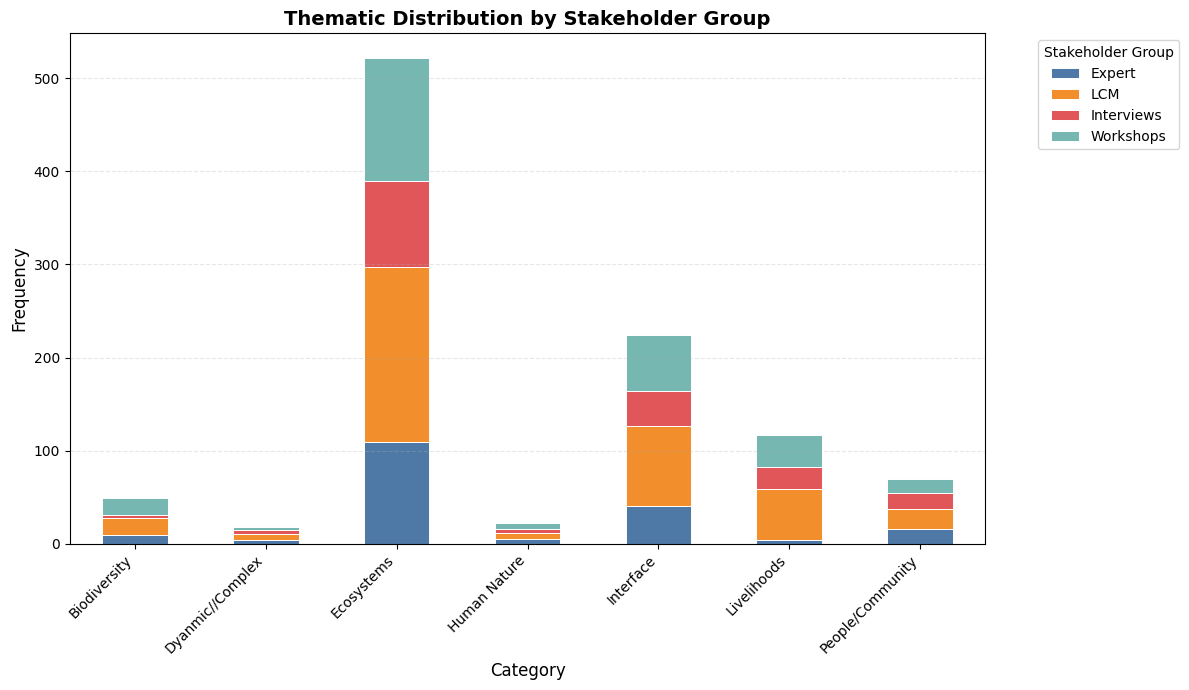

In [52]:
headers = ['Terms', 'Sub_Expert', 'Sub_LCM', 'Sub_Interviews', 'Sub_Workshops', 
           'Cat_LCM', 'Cat_Expert', 'Cat_Interviews', 'Cat_Workshops']
df = pd.read_csv('Data_Figures_nancy.csv', skiprows=2, names=headers)

current_category = None
cleaned_data = []

for idx, row in df.iterrows():
    if pd.notnull(row['Cat_LCM']):
        
        name = re.sub(r'^[0-9.]+\s*', '', str(row['Terms'])).strip()
        
     
        if "dynamic" in name.lower():
            name = "Dynamic/Complex"
        elif "people" in name.lower():
            name = "People/Community"
        elif "human" in name.lower():
            name = "Human Nature"
        else:
            name = name.title()
            
        current_category = name
    
    if any(pd.notnull(row[['Sub_Expert', 'Sub_LCM', 'Sub_Interviews', 'Sub_Workshops']])):
        cleaned_data.append({
            'Category': current_category,
            'Expert': row['Sub_Expert'],
            'LCM': row['Sub_LCM'],
            'Interviews': row['Sub_Interviews'],
            'Workshops': row['Sub_Workshops']
        })

df_clean = pd.DataFrame(cleaned_data)
df_clean[['Expert', 'LCM', 'Interviews', 'Workshops']] = df_clean[['Expert', 'LCM', 'Interviews', 'Workshops']].fillna(0)

# Group and Plot
plot_data = df_clean.groupby('Category')[['Expert', 'LCM', 'Interviews', 'Workshops']].sum()

# Plotting with 'tab20' for better distinction
ax = plot_data.plot(kind='bar', 
                    stacked=True, 
                    figsize=(12, 7), 
                    color=['#4e79a7', '#f28e2b', '#e15759', '#76b7b2'],
                    edgecolor='white',
                    linewidth=0.7)

plt.title('Thematic Distribution by Stakeholder Group', fontsize=14, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Stakeholder Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# Volume of mentions varies by engagement method:
LCM - 382

Workshops: 270

Expert: 187

Interviews: 182


# Conclusion
While all groups prioritize environmental and ecosystem-based topics, experts focus heavily on technical ecological frameworks, while local management and community members are more concerned with the practical, socio-economic impacts on livelihoods. To create more effective management strategies, expert-led frameworks should better integrate these community-driven livelihood priorities.